In [2]:
!pip install --upgrade torch_geometric

!pip install torch-scatter torch-sparse torch-cluster pyg-lib -f https://data.pyg.org/whl/torch-$(python -c 'import torch; print(torch.__version__)').html

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 44.4 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 104.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 4.0 MB/s eta 0:00:0000:0100:010m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 66.3 MB/s eta 0:00:00:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 98.8 MB/s eta 0:00:00:00:01


Step 1: Loading Data...
Step 4: Training Robust-TGAT...
Epoch 010 | Train Loss: 0.0063 | Val F1: 0.6283
Epoch 020 | Train Loss: 0.0063 | Val F1: 0.5434
Early stopping!

Step 5: Final Evaluation...

--- ROBUST-TGAT RESULTS ---
              precision    recall  f1-score   support

       Licit       0.97      1.00      0.98      8433
     Illicit       0.88      0.38      0.53       408

    accuracy                           0.97      8841
   macro avg       0.92      0.69      0.76      8841
weighted avg       0.97      0.97      0.96      8841

ROC AUC: 0.8509
Vẽ biểu đồ tổng hợp cho Robust-TGAT...
Đã lưu biểu đồ tổng hợp: 'robust_tgat_full_report.png'


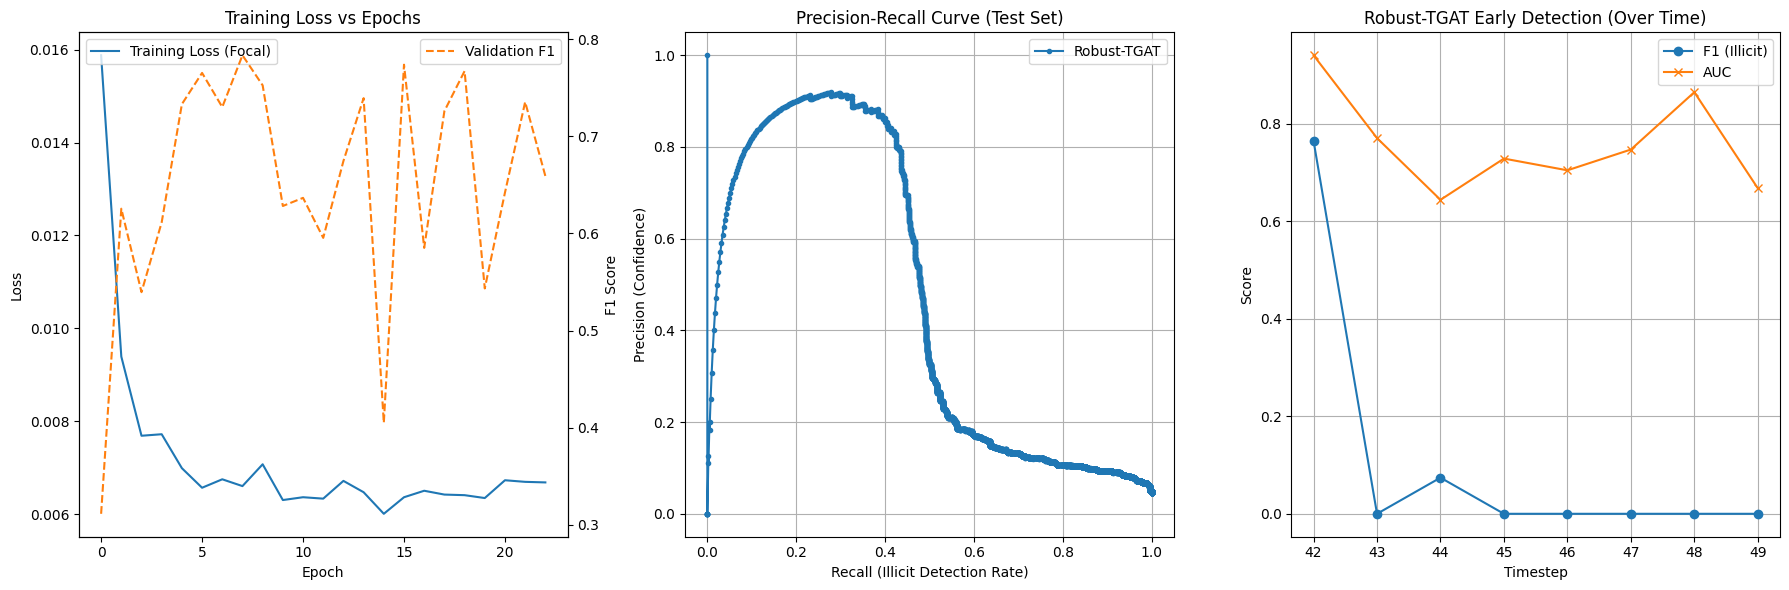

In [16]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import NeighborLoader
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import softmax
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, f1_score, precision_recall_curve, precision_score, recall_score
import matplotlib.pyplot as plt
import math

# --- 1. Load Data (Giữ nguyên) ---
print("Step 1: Loading Data...")
try:
    df_features = pd.read_csv('/kaggle/input/elliptic/elliptic/elliptic_txs_features.csv', header=None)
    df_classes = pd.read_csv('/kaggle/input/elliptic/elliptic/elliptic_txs_classes.csv')
    df_edgelist = pd.read_csv('/kaggle/input/elliptic/elliptic/elliptic_txs_edgelist.csv')
except FileNotFoundError:
    print("Error: CSV files not found.")
    exit()

feature_cols = ['txId', 'timestep'] + [f'local_{i}' for i in range(93)] + [f'agg_{i}' for i in range(72)]
df_features.columns = feature_cols
all_tx_ids = df_features['txId'].unique()
tx_id_map = {tx_id: i for i, tx_id in enumerate(all_tx_ids)}
df_edgelist['txId1_idx'] = df_edgelist['txId1'].map(tx_id_map)
df_edgelist['txId2_idx'] = df_edgelist['txId2'].map(tx_id_map)
df_merged = pd.merge(df_features, df_classes, on='txId', how='left')
df_merged['class'] = df_merged['class'].map({'2': 0, '1': 1, 'unknown': np.nan})
df_merged = df_merged.set_index('txId').loc[all_tx_ids].reset_index()

features_no_time = [col for col in df_features.columns if col not in ['txId', 'timestep']]
X_df = df_merged[features_no_time]
y_series = df_merged['class']
timesteps = df_merged['timestep'].values

# Train/Val/Test Split
train_mask_idx = X_df.index[(timesteps <= 34) & (y_series.notna())].values
val_mask_idx = X_df.index[(timesteps >= 35) & (timesteps <= 41) & (y_series.notna())].values
test_mask_idx = X_df.index[(timesteps >= 42) & (timesteps <= 49) & (y_series.notna())].values

scaler = StandardScaler()
X_train_features = X_df.loc[train_mask_idx]
scaler.fit(X_train_features)
X_scaled = scaler.transform(X_df)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

data = Data(
    x=torch.tensor(X_scaled, dtype=torch.float),
    edge_index=torch.tensor(df_edgelist[['txId1_idx', 'txId2_idx']].values.T, dtype=torch.long),
    y=torch.tensor(y_series.values, dtype=torch.long),
    ts=torch.tensor(timesteps, dtype=torch.float) 
)
data.train_mask = torch.tensor(train_mask_idx, dtype=torch.long)
data.val_mask = torch.tensor(val_mask_idx, dtype=torch.long)
data.test_mask = torch.tensor(test_mask_idx, dtype=torch.long)

# Loader với Neighbor Sampling
train_loader = NeighborLoader(data, num_neighbors=[10, 10], batch_size=1024, input_nodes=data.train_mask, shuffle=True)
val_loader = NeighborLoader(data, num_neighbors=[10, 10], batch_size=1024, input_nodes=data.val_mask)
test_loader = NeighborLoader(data, num_neighbors=[10, 10], batch_size=1024, input_nodes=data.test_mask)

# --- 2. Cải tiến: Focal Loss ---
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        BCE_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        F_loss = self.alpha * (1-pt)**self.gamma * BCE_loss
        return torch.mean(F_loss)

# --- 3. Robust-TGAT Model (With increased Dropout) ---
class TimeEncoder(nn.Module):
    def __init__(self, out_channels):
        super().__init__()
        self.w = nn.Linear(1, out_channels // 2) 
        self.p = nn.Linear(1, out_channels // 2)
    def forward(self, t):
        t = t.unsqueeze(-1)
        return torch.cat([torch.cos(self.w(t) + self.p(t)), torch.sin(self.w(t) + self.p(t))], dim=-1)

class TGATLayer(MessagePassing):
    def __init__(self, in_channels, out_channels, time_channels, heads=2, dropout=0.2): # Tăng dropout mặc định lên 0.2
        super().__init__(node_dim=0, aggr='add')
        self.heads = heads
        self.head_dim = out_channels // heads
        self.dropout = dropout
        
        total_in_dim = in_channels + time_channels
        self.lin_q = nn.Linear(total_in_dim, out_channels)
        self.lin_k = nn.Linear(total_in_dim, out_channels)
        self.lin_v = nn.Linear(total_in_dim, out_channels)
        self.lin_skip = nn.Linear(in_channels, out_channels)

    def forward(self, x, edge_index, t_emb):
        x_in = torch.cat([x, t_emb], dim=-1)
        q = self.lin_q(x_in).view(-1, self.heads, self.head_dim)
        k = self.lin_k(x_in).view(-1, self.heads, self.head_dim)
        v = self.lin_v(x_in).view(-1, self.heads, self.head_dim)

        out = self.propagate(edge_index, q=q, k=k, v=v, size=None)
        out = out.view(-1, self.heads * self.head_dim)
        out = out + self.lin_skip(x)
        return out

    def message(self, q_i, k_j, v_j, index, ptr, size_i):
        alpha = (q_i * k_j).sum(dim=-1) / np.sqrt(self.head_dim)
        alpha = softmax(alpha, index, ptr, size_i)
        
        # --- CẢI TIẾN: Dropout lên chính Attention Weights ---
        # Giúp tránh việc model quá tin vào một vài hàng xóm cụ thể
        alpha = F.dropout(alpha, p=self.dropout, training=self.training)
        return v_j * alpha.unsqueeze(-1)

class RobustTGATModel(nn.Module):
    def __init__(self, num_features, hidden_dim, num_classes, time_dim=32):
        super().__init__()
        self.time_enc = TimeEncoder(time_dim)
        # Tăng Dropout giữa các layer
        self.conv1 = TGATLayer(num_features, hidden_dim, time_dim, heads=4, dropout=0.3)
        self.conv2 = TGATLayer(hidden_dim, hidden_dim, time_dim, heads=4, dropout=0.3)
        self.lin_out = nn.Linear(hidden_dim, num_classes)
        self.dropout = nn.Dropout(p=0.4) # Dropout mạnh ở lớp cuối

    def forward(self, x, edge_index, t):
        t_emb = self.time_enc(t)
        x = F.relu(self.conv1(x, edge_index, t_emb))
        x = self.dropout(x) # Apply dropout
        x = F.relu(self.conv2(x, edge_index, t_emb))
        x = self.dropout(x) # Apply dropout
        out = self.lin_out(x)
        return F.log_softmax(out, dim=1)

# --- 4. Training Setup ---
print("Step 4: Training Robust-TGAT...")
model = RobustTGATModel(
    num_features=165, 
    hidden_dim=128, 
    num_classes=2,
    time_dim=64 # Tăng dimension thời gian để bắt pattern tốt hơn
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4) # Thêm weight_decay (L2 regularization)
loss_fn = FocalLoss(alpha=0.25, gamma=2.0) # Sử dụng Focal Loss thay vì CrossEntropy

# Training Loop
train_losses, val_losses = [], []
best_val_f1 = 0 # Theo dõi F1 thay vì Loss để save model
patience = 15   # Tăng patience

for epoch in range(100): # Tăng max epoch
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        # Time Jittering (Data Augmentation): Thêm nhiễu nhỏ vào thời gian
        # Giúp model không học vẹt mốc thời gian chính xác
        noise = (torch.rand_like(batch.ts) - 0.5) * 0.1 
        t_noisy = batch.ts + noise
        
        out = model(batch.x, batch.edge_index, t_noisy)
        loss = loss_fn(out[:batch.batch_size], batch.y[:batch.batch_size])
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    all_val_true, all_val_pred = [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.ts)
            pred = out[:batch.batch_size].argmax(dim=1)
            
            all_val_true.extend(batch.y[:batch.batch_size].cpu().numpy())
            all_val_pred.extend(pred.cpu().numpy())
            
    val_f1 = f1_score(all_val_true, all_val_pred, pos_label=1, zero_division=0)
    val_losses.append(val_f1) # Lưu F1 để vẽ biểu đồ (thực tế là metric, không phải loss)

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1:03d} | Train Loss: {avg_train_loss:.4f} | Val F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), 'best_robust_tgat.pth')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping!")
            break

# --- 5. Final Evaluation ---
print("\nStep 5: Final Evaluation...")
model.load_state_dict(torch.load('best_robust_tgat.pth'))
model.eval()

all_true, all_pred, all_proba, all_ts = [], [], [], []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.ts)
        
        target_out = out[:batch.batch_size]
        target_ts = batch.ts[:batch.batch_size].cpu().numpy()
        
        all_true.append(batch.y[:batch.batch_size].cpu().numpy())
        all_pred.append(target_out.argmax(dim=1).cpu().numpy())
        all_proba.append(target_out.exp()[:, 1].cpu().numpy())
        all_ts.append(target_ts)

y_true = np.concatenate(all_true)
y_pred = np.concatenate(all_pred)
y_proba = np.concatenate(all_proba)
timesteps_test = np.concatenate(all_ts)

print("\n--- ROBUST-TGAT RESULTS ---")
print(classification_report(y_true, y_pred, target_names=['Licit', 'Illicit']))
print(f"ROC AUC: {roc_auc_score(y_true, y_proba):.4f}")

# Visualize Early Detection
unique_ts = sorted(np.unique(timesteps_test))
f1_time, auc_time = [], []

for t in unique_ts:
    mask = (timesteps_test == t)
    if np.sum(mask) > 0 and len(np.unique(y_true[mask])) > 1:
        f1_time.append(f1_score(y_true[mask], y_pred[mask], pos_label=1, zero_division=0))
        auc_time.append(roc_auc_score(y_true[mask], y_proba[mask]))
    else:
        f1_time.append(0.0)
        auc_time.append(0.5)

#plt.figure(figsize=(12, 5))
#plt.plot(unique_ts, f1_time, marker='o', label='F1 (Illicit)')
#plt.plot(unique_ts, auc_time, marker='x', label='AUC')
#plt.title('Robust-TGAT Early Detection')
#plt.xlabel('Timestep')
#plt.ylabel('Score')
#plt.legend()
#plt.grid(True)
#plt.savefig('robust_tgat_results.png')
#print("Saved result plot.")
# --- Step 6: Full Visualization (Bổ sung) ---
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

print("Vẽ biểu đồ tổng hợp cho Robust-TGAT...")

plt.figure(figsize=(18, 6))

# 1. Biểu đồ Loss và Validation F1
# Lưu ý: Trong code Robust-TGAT, list 'val_losses' thực chất lưu trữ 'Val F1'
plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Training Loss (Focal)', color='tab:blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss vs Epochs')
plt.legend(loc='upper left')

# Tạo trục y thứ 2 để vẽ F1 (vì Loss giảm, F1 tăng, vẽ chung 1 trục sẽ khó nhìn)
ax2 = plt.gca().twinx()
ax2.plot(val_losses, label='Validation F1', color='tab:orange', linestyle='--')
ax2.set_ylabel('F1 Score')
ax2.legend(loc='upper right')
#plt.title('Training Loss & Validation F1')

# 2. Biểu đồ Precision-Recall (Tổng thể)
plt.subplot(1, 3, 2)
precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_proba, pos_label=1)
plt.plot(recall_curve, precision_curve, marker='.', label='Robust-TGAT')
plt.title('Precision-Recall Curve (Test Set)')
plt.xlabel('Recall (Illicit Detection Rate)')
plt.ylabel('Precision (Confidence)')
plt.grid(True)
plt.legend()

# 3. Biểu đồ Early Detection (Vẽ lại cho đồng bộ)
plt.subplot(1, 3, 3)
plt.plot(unique_ts, f1_time, marker='o', label='F1 (Illicit)')
plt.plot(unique_ts, auc_time, marker='x', label='AUC')
plt.title('Robust-TGAT Early Detection (Over Time)')
plt.xlabel('Timestep')
plt.ylabel('Score')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig('robust_tgat_full_report.png')
print("Đã lưu biểu đồ tổng hợp: 'robust_tgat_full_report.png'")
plt.show()

new

In [17]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import TransformerConv
from torch_geometric.nn.models.tgn import TGNMemory, IdentityMessage, LastAggregator
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, roc_auc_score, f1_score, precision_score, recall_score, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import time
import math
import gc

# --- Configuration ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on device: {device}")

MAX_EPOCHS = 50
PATIENCE = 5
MEMORY_DIM = 50
TIME_DIM = 50
EMBEDDING_DIM = 50

# --- Focal Loss (Sử dụng ignore_index=-1) ---
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, ignore_index=-1):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ignore_index = ignore_index

    def forward(self, inputs, targets):
        # inputs (logits): [N, C], targets: [N]
        BCE_loss = F.cross_entropy(inputs, targets, reduction='none', ignore_index=self.ignore_index)
        
        # Chỉ tính toán cho các phần tử không bị ignore
        valid_mask = targets != self.ignore_index
        if valid_mask.sum() == 0:
            # Trả về 0 loss nếu không có nhãn hợp lệ trong batch
            return torch.tensor(0.0, device=inputs.device, requires_grad=True)

        BCE_loss_valid = BCE_loss[valid_mask]
        
        pt = torch.exp(-BCE_loss_valid)
        F_loss = self.alpha * (1 - pt)**self.gamma * BCE_loss_valid
        
        return torch.mean(F_loss)

# --- Define TGN/TGAT Architecture ---
class GraphAttentionEmbedding(nn.Module):
    def __init__(self, in_channels, out_channels, msg_dim, time_enc):
        super().__init__()
        self.time_enc = time_enc
        edge_dim = msg_dim + time_enc.out_channels
        self.conv = TransformerConv(in_channels, out_channels // 2, heads=2,
                                    dropout=0.1, edge_dim=edge_dim)

    def forward(self, x, last_update, edge_index, t, msg):
        rel_t = t - last_update
        rel_t_emb = self.time_enc(rel_t.to(x.dtype))
        src_indices = edge_index[0]
        rel_t_emb_edges = rel_t_emb[src_indices]
        edge_attr = torch.cat([rel_t_emb_edges, msg], dim=-1)
        return self.conv(x, edge_index, edge_attr)

class TGNModel(nn.Module):
    def __init__(self, num_nodes, raw_feat_dim, memory_dim, time_dim, num_classes):
        super().__init__()
        self.num_nodes = num_nodes
        self.memory = TGNMemory(
            num_nodes=num_nodes,
            raw_msg_dim=raw_feat_dim,
            memory_dim=memory_dim,
            time_dim=time_dim,
            message_module=IdentityMessage(raw_feat_dim, memory_dim, time_dim),
            aggregator_module=LastAggregator()
        )
        self.gnn = GraphAttentionEmbedding(
            in_channels=memory_dim,
            out_channels=EMBEDDING_DIM,
            msg_dim=raw_feat_dim,
            time_enc=self.memory.time_enc,
        )
        self.mlp = nn.Sequential(
            nn.Linear(EMBEDDING_DIM, 64),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            nn.Linear(64, num_classes)
        )

    def forward(self, n_id, edge_index, edge_attr, edge_time):
        mem, last_update = self.memory(n_id)
        current_time = edge_time[0].repeat(len(n_id))
        embedding = self.gnn(mem, last_update, edge_index, current_time, edge_attr)
        out = self.mlp(embedding)
        return out

# Helper for re-indexing
def get_local_edge_index(src, dst, nodes, device, num_total_nodes):
    assoc = torch.full((num_total_nodes,), -1, dtype=torch.long, device=device)
    assoc[nodes] = torch.arange(nodes.size(0), device=device)
    return torch.stack([assoc[src], assoc[dst]], dim=0)


# --- Step 1 & 2: Load, Process, and Prepare Tensors (Memory Optimized) ---
print("--- Starting Data Processing ---")
try:
    df_features = pd.read_csv('/kaggle/input/elliptic/elliptic/elliptic_txs_features.csv', header=None)
    df_classes = pd.read_csv('/kaggle/input/elliptic/elliptic/elliptic_txs_classes.csv')
    df_edgelist = pd.read_csv('/kaggle/input/elliptic/elliptic/elliptic_txs_edgelist.csv')
except FileNotFoundError:/kaggle/input/elliptic/elliptic/elliptic_txs_features.csv
    print("Error: Files not found. Please ensure you have uploaded the 3 CSV files.")
    exit()

# Rename cols
if df_features.shape[1] == 167:
    col_names = ['txId', 'timestep'] + [f'local_{i}' for i in range(93)] + [f'agg_{i}' for i in range(72)]
    df_features.columns = col_names
else:
    new_cols = {0: 'txId', 1: 'timestep'}
    df_features.rename(columns=new_cols, inplace=True)

# Merge & Map
df_merged = pd.merge(df_features, df_classes, on='txId', how='left')
df_merged['class'] = df_merged['class'].map({'2': 0, '1': 1, 'unknown': -1}).fillna(-1).astype(np.int8)

all_tx_ids = df_merged['txId'].unique()
tx_id_map = {tx_id: i for i, tx_id in enumerate(all_tx_ids)}
df_merged['node_idx'] = df_merged['txId'].map(tx_id_map).astype(np.int32)
num_total_nodes = len(all_tx_ids)

df_edgelist['src_idx'] = df_edgelist['txId1'].map(tx_id_map).astype(np.int32)
df_edgelist['dst_idx'] = df_edgelist['txId2'].map(tx_id_map).astype(np.int32)

node_ts_map = dict(zip(df_merged['node_idx'], df_merged['timestep']))
df_edgelist['timestep'] = df_edgelist['src_idx'].map(node_ts_map).astype(np.int32)
df_edgelist = df_edgelist.sort_values('timestep').reset_index(drop=True)
df_merged = df_merged.sort_values('timestep').reset_index(drop=True)

feature_cols_only = [c for c in df_merged.columns if c not in ['txId', 'timestep', 'class', 'node_idx']]
X_all = df_merged[feature_cols_only].values.astype(np.float32)
y_all = df_merged['class'].values
ts_all = df_merged['timestep'].values
NUM_FEATURES = X_all.shape[1]

train_mask = (ts_all <= 34)
scaler = StandardScaler()
scaler.fit(X_all[train_mask])
X_all = scaler.transform(X_all)

# Class weights
y_train = y_all[(ts_all <= 34) & (y_all != -1)]
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_tensor = torch.tensor(weights, dtype=torch.float).to(device)


# --- GIẢI PHÓNG BỘ NHỚ ---
del df_features, df_classes, df_merged, y_train, train_mask
gc.collect()

X_tensor = torch.tensor(X_all, dtype=torch.float)
y_tensor = torch.tensor(y_all, dtype=torch.long)

edges_by_step = {}
for t in range(1, 50):
    step_edges = df_edgelist[df_edgelist['timestep'] == t]
    if not step_edges.empty:
        edges_by_step[t] = {
            'src': torch.tensor(step_edges['src_idx'].values, dtype=torch.long),
            'dst': torch.tensor(step_edges['dst_idx'].values, dtype=torch.long),
            'ts': torch.tensor(step_edges['timestep'].values, dtype=torch.long)
        }
del df_edgelist, X_all, ts_all
gc.collect()
print("--- Data Processing Complete ---")

# --- Step 3: Initialize Model ---
model = TGNModel(
    num_nodes=num_total_nodes,
    raw_feat_dim=NUM_FEATURES,
    memory_dim=MEMORY_DIM,
    time_dim=TIME_DIM,
    num_classes=2
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0003, weight_decay=1e-4)
loss_fn = FocalLoss(alpha=0.25, gamma=2.0, ignore_index=-1)

# --- Step 4: Training Loop (Sequential, Memory Optimized) ---
print("\nStarting Training...")
train_losses = []
val_losses = []
best_val_loss = float('inf')
best_val_f1 = 0
patience_counter = 0

for epoch in range(MAX_EPOCHS):
    start_time = time.time()
    model.memory.reset_state()
    
    # TRAIN (T1-T34)
    model.train()
    total_loss = 0
    batch_cnt = 0
    
    for t in range(1, 35):
        if t not in edges_by_step: continue
        batch_data = edges_by_step[t]
        
        src = batch_data['src'].to(device)
        dst = batch_data['dst'].to(device)
        t_tensor = batch_data['ts'].to(device)
        t_tensor_float = t_tensor.float() # FIX: Tạo bản sao float cho jittering
        
        nodes = torch.cat([src, dst]).unique()
        edge_index_local = get_local_edge_index(src, dst, nodes, device, num_total_nodes)
        
        # Data Augmentation (Time Jittering)
        # Sửa lỗi: Dùng t_tensor_float cho rand_like()
        noise = (torch.rand_like(t_tensor_float) - 0.5) * 0.1 
        t_noisy = t_tensor_float + noise
        
        batch_edge_attr = X_tensor[src.cpu()].to(device)
        
        optimizer.zero_grad()
        logits = model(nodes, edge_index_local, batch_edge_attr, t_noisy)
        batch_y = y_tensor[nodes.cpu()].to(device)
        
        loss = loss_fn(logits, batch_y)
        loss.backward()
        optimizer.step()
        
        # Update Memory & Detach (Dùng t_tensor gốc - Long)
        model.memory.update_state(src, dst, t_tensor, batch_edge_attr)
        model.memory.detach()
        
        total_loss += loss.item()
        batch_cnt += 1
        
    avg_train_loss = total_loss / batch_cnt
    train_losses.append(avg_train_loss)

    # VALIDATION (T35-T41) - Proxy Evaluation
    model.eval()
    val_total_loss = 0
    val_cnt = 0
    all_val_true, all_val_pred = [], []
    with torch.no_grad():
        for t in range(35, 42):
            if t not in edges_by_step: continue
            batch_data = edges_by_step[t]
            src = batch_data['src'].to(device)
            dst = batch_data['dst'].to(device)
            t_tensor = batch_data['ts'].to(device)
            
            nodes = torch.cat([src, dst]).unique()
            edge_index_local = get_local_edge_index(src, dst, nodes, device, num_total_nodes)
            batch_edge_attr = X_tensor[src.cpu()].to(device)
            
            # Prediction dùng t_tensor.float()
            logits = model(nodes, edge_index_local, batch_edge_attr, t_tensor.float())
            batch_y = y_tensor[nodes.cpu()].to(device)
            
            l = loss_fn(logits, batch_y)
            val_total_loss += l.item()
            val_cnt += 1
            
            pred = logits.argmax(dim=1)
            all_val_true.extend(batch_y.cpu().numpy())
            all_val_pred.extend(pred.cpu().numpy())
            
            model.memory.update_state(src, dst, t_tensor, batch_edge_attr)
            
    avg_val_loss = val_total_loss / val_cnt
    
    val_mask = np.array(all_val_true) != -1
    val_f1 = f1_score(np.array(all_val_true)[val_mask], np.array(all_val_pred)[val_mask], pos_label=1, zero_division=0)
    val_losses.append(val_f1)
    
    print(f"Epoch {epoch+1:02d} | Train Loss: {avg_train_loss:.4f} | Val F1: {val_f1:.4f} | Time: {time.time()-start_time:.1f}s")
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), 'best_robust_tgat.pth')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping triggered!")
            break
            
    gc.collect()
    torch.cuda.empty_cache()

# --- Step 5: Final Evaluation (Test) ---
print("\nRunning Final Evaluation on Test set...")
model.load_state_dict(torch.load('best_robust_tgat.pth'))
model.eval()

# Replay T1-T41
model.memory.reset_state()
with torch.no_grad():
    for t in range(1, 42):
        if t not in edges_by_step: continue
        batch_data = edges_by_step[t]
        src = batch_data['src'].to(device)
        dst = batch_data['dst'].to(device)
        t_tensor = batch_data['ts'].to(device)
        batch_edge_attr = X_tensor[src.cpu()].to(device)
        model.memory.update_state(src, dst, t_tensor, batch_edge_attr)

all_true, all_pred, all_prob, ts_list = [], [], [], []
f1_list, auc_list = [], []

with torch.no_grad():
    for t in range(42, 50):
        if t not in edges_by_step: continue
        step_df = edges_by_step[t]
        src = torch.tensor(step_df['src_idx'].values, dtype=torch.long).to(device)
        dst = torch.tensor(step_df['dst_idx'].values, dtype=torch.long).to(device)
        t_tensor = torch.tensor(step_df['timestep'].values, dtype=torch.long).to(device)
        nodes = torch.cat([src, dst]).unique()
        
        edge_index_local = get_local_edge_index(src, dst, nodes, device, num_total_nodes)
        batch_edge_attr = X_tensor[src.cpu()].to(device)
        
        logits = model(nodes, edge_index_local, batch_edge_attr, t_tensor.float())
        prob = torch.softmax(logits, dim=1)[:, 1]
        pred = logits.argmax(dim=1)
        
        batch_y = y_tensor[nodes.cpu()].numpy()
        mask = (batch_y != -1)
        
        if mask.sum() > 0:
            y_t = batch_y[mask]
            y_p = pred.cpu().numpy()[mask]
            y_pr = prob.cpu().numpy()[mask]
            
            all_true.extend(y_t)
            all_pred.extend(y_p)
            all_prob.extend(y_pr)
            
            f1 = f1_score(y_t, y_p, pos_label=1, zero_division=0)
            try:
                auc = roc_auc_score(y_t, y_pr)
            except:
                auc = 0.5
            f1_list.append(f1)
            auc_list.append(auc)
            ts_list.append(t)
            
        model.memory.update_state(src, dst, t_tensor, batch_edge_attr)

# --- Step 6: Final Reporting ---
precision_illicit = precision_score(all_true, all_pred, pos_label=1)
recall_illicit = recall_score(all_true, all_pred, pos_label=1)
f1_illicit = f1_score(all_true, all_pred, pos_label=1)
auc_score = roc_auc_score(all_true, all_prob)
macro_f1 = f1_score(all_true, all_pred, average='macro', zero_division=0)
weighted_f1 = f1_score(all_true, all_pred, average='weighted', zero_division=0)


print("\n--- FINAL ROBUST-TGAT RESULTS ---")

print("Metrics for 'Illicit' (Class 1):")
print(f"  Precision: {precision_illicit:.4f}")
print(f"  Recall:    {recall_illicit:.4f}")
print(f"  F1-Score:  {f1_illicit:.4f}")

print("\nOverall Metrics:")
print(f"  ROC AUC:   {auc_score:.4f}")
print(f"  Macro F1:    {macro_f1:.4f}")
print(f"  Weighted F1: {weighted_f1:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(all_true, all_pred, target_names=['Licit', 'Illicit']))

# --- Step 7: Plotting (Đồng bộ hóa 3 biểu đồ) ---
print("\nStarting Plotting...")
plt.figure(figsize=(18, 6))

# 1. Loss Curve / Val F1
plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train Loss', color='tab:blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss & Validation F1')
plt.legend(loc='upper left')

ax2 = plt.gca().twinx()
ax2.plot(val_losses, label='Val F1', color='tab:orange', linestyle='--')
ax2.set_ylabel('F1 Score')
ax2.legend(loc='upper right')


# 2. Precision-Recall Curve (Overall)
plt.subplot(1, 3, 2)
prec, rec, _ = precision_recall_curve(all_true, all_prob, pos_label=1)
plt.plot(rec, prec, marker='.', label='Robust-TGAT')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)


# 3. Early Detection
plt.subplot(1, 3, 3)
plt.plot(ts_list, f1_list, marker='o', label='F1 (Illicit)')
plt.plot(ts_list, auc_list, marker='x', label='AUC')
plt.title('Robust-TGAT Early Detection (Over Time)')
plt.xlabel('Timestep')
plt.ylabel('Score')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig('robust_tgat_full_report.png')
print("Đã lưu biểu đồ tổng hợp.")

SyntaxError: invalid syntax (1000721270.py, line 113)